### 📊 **ERA5 재분석 데이터: 전 세계 2m 기온**

---

# 📝 **소개**

이 노트북은
**유럽중기예보센터(ECMWF)**에서 제공하는
**전 세계 2미터 높이의 기온 데이터(T2M)**를
다운받고 살펴보는 방법을 보여줍니다.(https://www.ecmwf.int/en/forecasts/datasets/reanalysis-datasets/era5).

우리는 먼저 전 세계 기온 데이터를 가져온 뒤,
이를 한반도 지역으로 좁혀서
분석하고 시각화할 거예요.

---

## 🚀 **이 노트북의 주요 작업**

1. **📥 ERA5 전 세계 2m 기온(T2M) 데이터 다운로드**  
   - Copernicus Climate Data Store (CDS) API를 사용해**재분석 데이터(ERA5)**를 가져옵니다.
  - **전 세계 범위(global domain)**를 지정하고,원하는 기간의 T2M(2m 기온) 데이터를 추출합니다.

2. **🔍 NetCDF 데이터 탐색 및 시각화**  
   - 다운로드한 NetCDF(.nc) 파일을 열고,그 **구조(데이터 구성)**를 살펴봅니다.
  - cartopy와 matplotlib를 사용해 전 세계 기온 지도를 시각화합니다.
  - 데이터를 한반도 지역으로 잘라내어(subset)
  지역별 기온 지도를 그려봅니다.

---

## 📝 **연습 과제**
노트북 전반에 걸쳐, 연습 과제들이 등장할 거예요. 이 과제들은 ERA5 데이터 처리, 원하는 지역만 잘라내기(subsetting), 시각화하는 핵심 과정을 직접 적용하고 익히는 데 도움을 줄 거예요.

---

Let’s begin! 🚀

# ⚙️ **1. Set-up**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 📁 CDS API 설정 파일을 Google Drive에 저장할 경로 지정
cdsapi_drive_path = "/content/drive/MyDrive/Weather_BigData/cdsapirc"

# 🔐 CDS API 키를 입력 (여기서는 예시 값이므로 실제 키로 교체해야 함)
CDS_API_KEY = "12345678-xxxx-xxxx-xxxx-xxxxxxxxxxxx"

# 📄 CDS API 설정 파일 내용을 문자열로 생성
# - url: CDS API의 기본 접속 주소
# - key: 사용자 개인 API 키
# - verify: 인증서 검증 비활성화 (코랩에서는 인증 관련 경고를 피하기 위해 0으로 설정)
cdsapi_config = f"""
url: https://cds.climate.copernicus.eu/api/v2
key: {CDS_API_KEY}
verify: 0
"""

# 📝 설정 파일을 실제로 Google Drive에 저장
# - 이 파일이 있어야 CDS API로 데이터를 다운로드할 수 있음
with open(cdsapi_drive_path, "w") as f:
    f.write(cdsapi_config)

# ✅ 성공 메시지 출력
print(f"✅ API Key가 Google Drive에 저장되었습니다: {cdsapi_drive_path}")


✅ API Key가 Google Drive에 저장되었습니다: /content/drive/MyDrive/Weather_BigData/cdsapirc


In [ ]:
import shutil

# Copy the API Key from Google Drive to ~/.cdsapirc
shutil.copy("/content/drive/MyDrive/Weather_BigData/cdsapirc", "/root/.cdsapirc")

print("✅ API Key successfully loaded from Google Drive!")

✅ API Key successfully loaded from Google Drive!


# **2. ERA5 재분석자료 다운로드**

In [ ]:
!pip install cdsapi

In [ ]:
import cdsapi
import os

# Set the save path in Google Drive
save_path = "/content/drive/MyDrive/Weather_BigData/era5_t2m_202404.nc"

# Initialize the CDS API client
dataset = "derived-era5-single-levels-daily-statistics"
# dataset = 'reanalysis-era5-single-levels'
request = {
    "product_type": "reanalysis",
    "variable": ["2m_temperature"],
    "year": "2024",
    "month": ["04"],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30"
    ],
    "daily_statistic": "daily_mean",
    "time_zone": "utc+00:00",
    "frequency": "1_hourly"
}


# Request and save the data
client = cdsapi.Client()
client.retrieve(dataset, request, save_path)


print(f"✅ ERA5 daily temperature data download complete! Saved to Google Drive: {save_path}")

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/datapi/api_client.py:83: UserWarning: 404 Client Error: Not Found for url: https://cds.climate.copernicus.eu/api/v2/catalogue/v1/messages

  warnings.warn(str(exc), UserWarning)
/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


HTTPError: 404 Client Error: Not Found for url: https://cds.climate.copernicus.eu/api/v2/retrieve/v1/processes/derived-era5-single-levels-daily-statistics


# **3. NetCDF 데이터 다루기**

In [ ]:
# netCDF4 설치
!pip install netCDF4
# GEOS, PROJ, 기타 의존성 설치
!apt-get install -y libproj-dev proj-data proj-bin \
                    libgeos-dev libgeos++-dev

# Cython과 pyshp 등 필요한 패키지 설치
!pip install cython numpy pyshp shapely

# Cartopy 설치
!pip install cartopy
print("Cartopy installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.0 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgeos-dev is already the newest version (3.11.1-1~jammy0).
libgeos-dev set to manually installed.
libproj-dev is already the newest version (9.1.1-1~jammy0).
libproj-dev set to manually installed.
proj-data is already the newest version (9.1.1-1~jammy0).
proj-data set to manually installed.
Suggested packages:
  libgdal-doc
The following NEW packages will be installed:
  libgeos++-dev proj-bin
0 upgraded, 2 newly installed, 0 to remove and 30 not upgraded.
Need to get 590 kB of archives.
After this operation, 3,515 kB of additional disk space will be used.
Get:1 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 libgeos++-dev amd64 3.11.1-1~jammy0 [393 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu ja

In [ ]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
# 🔧 NetCDF 파일 경로 정의
file_path = "/content/drive/MyDrive/Weather_BigData/era5_t2m_202404.nc"  # 본인의 실제 파일 경로로 수정할 것

# 📂 NetCDF 파일 열기 (읽기 전용 모드로 열기)
dataset = nc.Dataset(file_path, mode='r')

# 📄 NetCDF 파일 기본 정보 출력
print("📂 NetCDF 파일 정보")
print(f"파일 포맷: {dataset.file_format}\n")

# 🌍 NetCDF 전역 속성(Global Attributes) 출력
# → 이 데이터셋 자체에 대한 메타 정보 (설명, 생성일, 출처 등)
print("🌍 전역 속성:")
for attr in dataset.ncattrs():
    print(f"  {attr}: {getattr(dataset, attr)}")

# 📏 차원 정보 출력
# → 보통 시간(time), 위도(latitude), 경도(longitude)로 구성됨
print("\n📏 차원 정보:")
for dim_name, dim in dataset.dimensions.items():
    print(f"  {dim_name}: {len(dim)}")  # 각 차원의 이름과 크기 출력

# 📊 변수 정보 및 속성 출력
# → 실제 측정 데이터 (예: 기온, 습도 등)가 들어 있는 변수들
print("\n📊 변수 및 속성:")
for var_name, var in dataset.variables.items():
    print(f"\n🔹 변수 이름: {var_name}")
    print(f"   차원 구성: {var.dimensions}")
    print(f"   데이터 타입: {var.dtype}")

# ✅ 출력 완료 메시지
print("\n✅ NetCDF 파일 세부 정보 출력 완료!")

📂 NetCDF 파일 정보
파일 포맷: NETCDF4

🌍 전역 속성:
  GRIB_centre: ecmf
  GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
  GRIB_subCentre: 0
  Conventions: CF-1.7
  institution: European Centre for Medium-Range Weather Forecasts
  history: 2025-02-13T18:22 GRIB to CDM+CF via cfgrib-0.9.15.0/ecCodes-2.39.0 with {"source": "2m_temperature.grib", "filter_by_keys": {"stream": ["oper"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}
earthkit.transforms.aggregate.temporal.daily_reduce(2m_temperature_stream-oper, how=mean, **{'time_shift': {'hours': 0}})

📏 차원 정보:
  valid_time: 30
  latitude: 721
  longitude: 1440

📊 변수 및 속성:

🔹 변수 이름: t2m
   차원 구성: ('valid_time', 'latitude', 'longitude')
   데이터 타입: float32

🔹 변수 이름: number
   차원 구성: ()
   데이터 타입: int64

🔹 변수 이름: latitude
   차원 구성: ('latitude',)
   데이터 타입: float64

🔹 변수 이름: longitude
   차원 구성: ('longitude',)
   데이터 타입: float64

🔹 변수 이름: valid_time
   차원 구성: ('valid_time',)
   데이터 타입: int64

✅ NetCDF 파일 세부 정보 출력 

In [ ]:
# 📌 NetCDF 파일에서 위도(latitude)와 경도(longitude) 정보 추출
latitudes = dataset.variables["latitude"][:]  # 위도 배열
longitudes = dataset.variables["longitude"][:]  # 경도 배열

# 🌍 위도와 경도의 최소/최대 범위 출력
print("🗺 Latitude Range:", latitudes.min(), "to", latitudes.max())  # 예: -90.0 ~ 90.0
print("🗺 Longitude Range:", longitudes.min(), "to", longitudes.max())  # 예: 0.0 ~ 360.0 또는 -180 ~ 180

# 📦 확인할 변수 이름 지정 (예: 2m 높이의 기온은 "t2m")
variable_name = "t2m"

# 해당 변수명이 데이터셋에 존재하는지 확인
if variable_name in dataset.variables:
    var_data = dataset.variables[variable_name]

    # 🔍 변수의 shape(차원 정보) 출력
    # 일반적으로 (시간, 위도, 경도) 형태로 되어 있음
    print(f"\n📊 변수명: {variable_name}")
    print(f"   데이터 구조 (Shape): {var_data.shape}")
else:
    # ❌ 변수명이 데이터셋에 없을 경우 경고 출력
    print(f"❌ 변수 '{variable_name}'를 찾을 수 없습니다.")

# ✅ 처리 완료 메시지 출력
print("\n✅ NetCDF 파일 정보 출력 완료!")


🗺 Latitude Range: -90.0 to 90.0
🗺 Longitude Range: -180.0 to 179.75

📊 변수명: t2m
   데이터 구조 (Shape): (30, 721, 1440)

✅ NetCDF 파일 정보 출력 완료!


In [ ]:
# 🌍 위도(latitude), 경도(longitude), 변수 데이터 추출
lats = dataset.variables["latitude"][:]     # 위도 배열 불러오기
lons = dataset.variables["longitude"][:]    # 경도 배열 불러오기

variable_name = "t2m"  # 사용할 변수 이름 (예: 2m 기온)

### 🌡️ 변수 데이터 추출 (시간, 위도, 경도 순서로 3차원 배열)
data = dataset.variables["t2m"][:, :, :]

### 📅 월평균 계산하기
print(data.shape)  # 원본 데이터의 형태 출력 (예: (30일, 721, 1440))
mean_data = np.mean(data, axis=0)  # 시간 축(0번 축)을 따라 평균 → (위도, 경도) 형태의 평균값
print(mean_data.shape)  # 월평균 데이터 형태 출력


(30, 721, 1440)
(721, 1440)


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


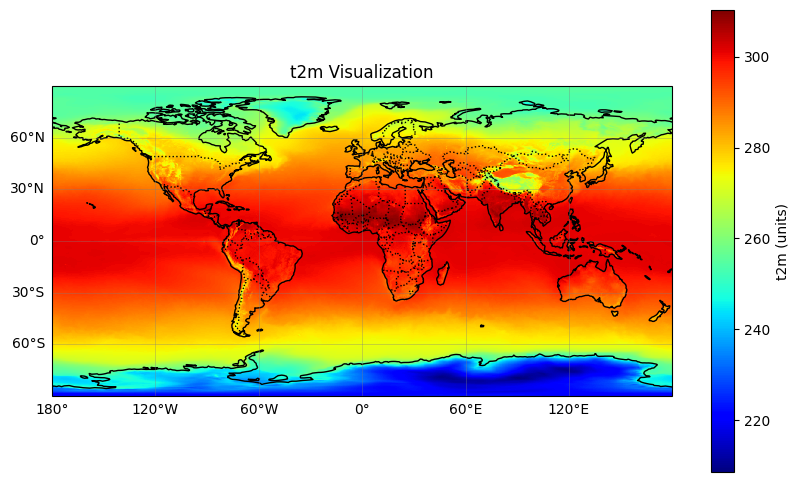

In [ ]:
# 1. 🗺️ 도화지 생성 및 투영법 설정 (PlateCarree = 원통 등거리 투영법, 'cylindrical'과 유사)
fig = plt.figure(figsize=(10, 6))  # 그림 크기 설정
ax = plt.axes(projection=ccrs.PlateCarree())  # 지도 좌표계 설정 (Cartopy의 PlateCarree 사용)

# 2. 🧭 지도의 표시 범위 설정 (지도 경계 설정)
ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=ccrs.PlateCarree())

# 3. 🌍 지도 요소 추가 (해안선, 국경선, 육지/바다 배경)
ax.coastlines()  # 해안선 추가
ax.add_feature(cfeature.BORDERS, linestyle=':')  # 국경선 추가 (점선)
ax.add_feature(cfeature.LAND, facecolor='lightgray')  # 육지 색상 설정
ax.add_feature(cfeature.OCEAN, facecolor='white')     # 바다 색상 설정

# 4. 📐 위도/경도 격자선 추가
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
gl.top_labels = False  # 상단 격자선 라벨 제거
gl.right_labels = False  # 우측 격자선 라벨 제거

# 5. 🧮 위도-경도 좌표쌍 그리드 생성 (mean_data와 일치시켜야 함)
lon, lat = np.meshgrid(lons, lats)  # 경도/위도 2차원 배열 생성

# 6. 🖼️ 평균 데이터 시각화 (pcolormesh: 컬러 매핑으로 데이터 표시)
c = ax.pcolormesh(lon, lat, mean_data, transform=ccrs.PlateCarree(),
                  cmap='jet', shading='auto')  # 색상 맵 'jet' 사용

# 7. 🎨 컬러바 추가 (색상이 나타내는 값 표시)
plt.colorbar(c, ax=ax, orientation='vertical', label=f"{variable_name} (units)")

# 8. 📝 제목 추가
plt.title(f"{variable_name} Visualization")

# 9. 👀 시각화 결과 보여주기
plt.show()


# **4. 한반도 부분만 추리기**

In [ ]:
# 🗺️ 한반도 영역 설정 (위도/경도 범위 지정)
lat_min, lat_max = 33.0, 39.5  # 한반도 위도 범위 (남쪽~북쪽)
lon_min, lon_max = 124.0, 131.5  # 한반도 경도 범위 (서쪽~동쪽)

# 📌 NetCDF 파일에서 위도, 경도, 2m 기온 데이터(t2m) 추출
lats = dataset.variables["latitude"][:]  # 위도 배열
lons = dataset.variables["longitude"][:]  # 경도 배열
data = dataset.variables["t2m"][:, :, :]  # 시간-위도-경도 순서의 기온 데이터

# 📉 시간 축 평균을 통해 월평균 기온 계산
mean_data = np.mean(data, axis=0)  # (lat, lon) 형태의 평균값

# 🔍 한반도 영역에 해당하는 위도/경도 인덱스 범위 찾기
lat_idx = np.where((lats >= lat_min) & (lats <= lat_max))[0]  # 조건에 맞는 위도 인덱스들
lon_idx = np.where((lons >= lon_min) & (lons <= lon_max))[0]  # 조건에 맞는 경도 인덱스들

# 🔢 인덱스 개수 출력 (해당 영역에 속하는 위도/경도 개수)
print(lat_idx.shape, lon_idx.shape)


(27,) (31,)


In [ ]:
### Subset the data and coordinate arrays
# ➤ 위도, 경도, 데이터 배열에서 한반도 범위만 잘라냄 (슬라이싱)

subset_lats = lats[lat_idx.min():lat_idx.max()+1]
# ▶ 한반도 범위에 해당하는 위도 값들만 추출

subset_lons = lons[lon_idx.min():lon_idx.max()+1]
# ▶ 한반도 범위에 해당하는 경도 값들만 추출

subset_data = mean_data[lat_idx.min():lat_idx.max()+1, lon_idx.min():lon_idx.max()+1]
# ▶ 월평균 기온 데이터에서 한반도 영역만 잘라냄 (위도 x 경도 크기의 2차원 배열)

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


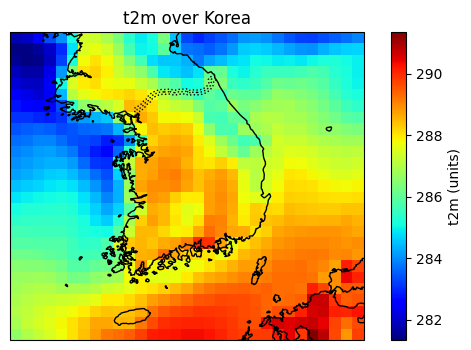

In [ ]:
# 1. Create the figure and set projection (PlateCarree = 'cylindrical')
fig = plt.figure(figsize=(7, 4))
# ▶ 출력될 그래프의 크기를 설정 (가로 7인치, 세로 4인치)

ax = plt.axes(projection=ccrs.PlateCarree())
# ▶ 지도 투영법 설정: PlateCarree는 위도/경도를 직사각형으로 나타내는 기본 투영법

# 2. Add map features
ax.coastlines()  # ▶ 해안선 추가
ax.add_feature(cfeature.BORDERS, linestyle=':')  # ▶ 나라 경계선 추가 (점선 스타일)
ax.add_feature(cfeature.LAND, facecolor='lightgray')  # ▶ 육지를 밝은 회색으로 채움
ax.add_feature(cfeature.OCEAN, facecolor='white')  # ▶ 바다를 흰색으로 채움

# 3. Create meshgrid for lat/lon (if not already done)
lon, lat = np.meshgrid(subset_lons, subset_lats)
# ▶ 위도/경도 좌표를 매핑할 수 있는 2차원 격자 생성 (지도 위에 데이터를 정확히 매핑하기 위함)

# 4. Plot the data (pcolormesh)
c = ax.pcolormesh(lon, lat, subset_data, transform=ccrs.PlateCarree(), cmap='jet', shading='auto')
# ▶ 평균 기온 데이터를 색깔로 표현함 (pcolormesh: 격자 데이터 시각화, cmap='jet': 파랑~빨강 색상 사용)

# 5. Add colorbar
plt.colorbar(c, ax=ax, orientation='vertical', label=f"{variable_name} (units)")
# ▶ 오른쪽에 색상 바 추가 (단위 라벨 표시)

# 6. Add title
plt.title(f"{variable_name} over Korea")
# ▶ 그래프 제목 설정

# 7. Show plot
plt.show()
# ▶ 그래프 화면에 표시
